<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Import Libraries</h2>
</div>

In [18]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import json
from numpy.polynomial import polynomial as P
from scipy.optimize import curve_fit

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Setup Saving</h2>
</div>

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Helpfl Functions</h2>
</div>

In [9]:
def load_run(parent_dir, run_number):
    parent_dir = Path(parent_dir)
    run_folder = next(parent_dir.glob(f"*_{run_number:03d}"))
    
    data = np.load(run_folder / "odmr_data.npz")
    with open(run_folder / "metadata.json") as f:
        metadata = json.load(f)
    
    run = dict(metadata)  # start with metadata fields
    run["frequencies"] = data["frequencies"]
    run["signal"] = data["signal"]
    run["reference"] = data["reference"]
    run["contrast"] = data["contrast"]
    run["run_folder"] = run_folder  # handy to keep around
    
    return run

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Import Data</h2>
</div>

How to index example:

    runs[5]["signal"]
    runs[5]["reference"]
    runs[5]["frequencies"]
    runs[5]["laser_power"]
    runs[5]["mw_gain"]
    runs[5]["reps"]
    runs[5]["ND Filter OD"]
    runs[5]["relax_delay_treg"]
    runs[5]["sweep_start_fGHz"]
    runs[5]["sweep_stop_fGHz"]
    runs[5]["sweep_step_fGHz"]


In [10]:
parent_dir = "/Volumes/hlab-nas/Data/DefectMsmts/Data/Albania/ODMR"
run_numbers = [5]  # add more run numbers here as you get them, e.g. [5, 6, 7]

runs = {n: load_run(parent_dir, n) for n in run_numbers}

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">See Shape</h3>
</div>

In [3]:
frequencies = data['frequencies']
signal = data['signal']
reference = data['reference']  # imported but unused for now

print(frequencies.shape, signal.shape)

(1001,) (1001,)


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Plot Raw Data</h2>
</div>

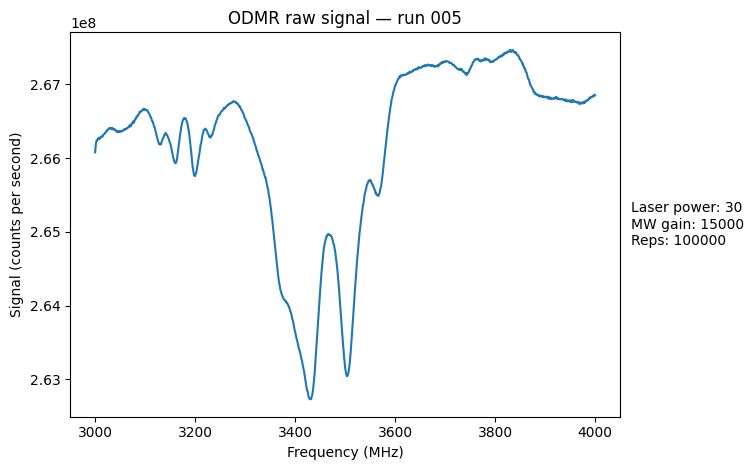

In [13]:
fig, ax = plt.subplots()
ax.plot(frequencies, signal)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (counts per second)")
ax.set_title(f"ODMR raw signal — run {run_number}")

info_text = (
    f"Laser power: {runs[5]['laser_power']}\n"
    f"MW gain: {runs[5]['mw_gain']}\n"
    f"Reps: {runs[5]['reps']}"
)
fig.text(1.02, 0.5, info_text, transform=ax.transAxes, va="center", ha="left", fontsize=10)

plt.tight_layout()
plt.show()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Fit Wings for Baseline</h3>
</div>

<div style="background-color:#FFEA00; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Fit Function</h4>
</div>

In [15]:

def fit_baseline(freqs, sig, mask, degree=3):
    coeffs = np.polyfit(freqs[mask], sig[mask], degree)
    return np.poly1d(coeffs)


In [16]:
# main resonance dip region to always exclude from baseline fit
dip_mask = (frequencies > 3350) & (frequencies < 3600)

# Version A: include the bump region in the baseline fit
wings_include = ~dip_mask

# Version B: exclude the bump region too
bump_mask = (frequencies > 3000) & (frequencies < 3350)
wings_exclude = wings_include & ~bump_mask

baseline_include = fit_baseline(frequencies, signal, wings_include)
baseline_exclude = fit_baseline(frequencies, signal, wings_exclude)

<div style="background-color:#FFEA00; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Plot</h4>
</div>

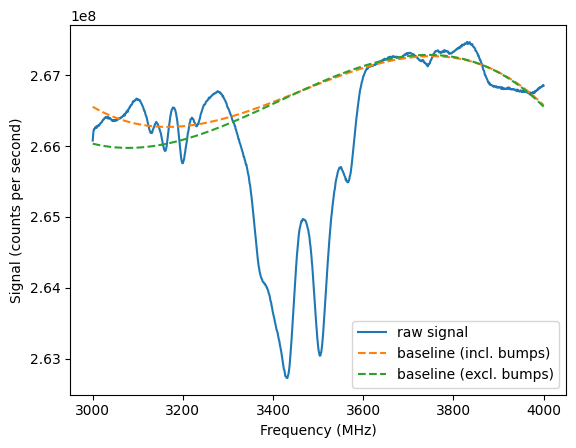

In [17]:
fig, ax = plt.subplots()
ax.plot(frequencies, signal, label="raw signal")
ax.plot(frequencies, baseline_include(frequencies), label="baseline (incl. bumps)", linestyle="--")
ax.plot(frequencies, baseline_exclude(frequencies), label="baseline (excl. bumps)", linestyle="--")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (counts per second)")
ax.legend()
plt.show()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Lorentzian Fit for Dips</h3>
</div>

<div style="background-color:#FFEA00; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Fit Functions</h4>
</div>

In [22]:
def lorentzian(f, f0, width, amp):
    return amp * (width/2)**2 / ((f - f0)**2 + (width/2)**2)

def model(f, baseline_vals, f1, w1, a1, f2, w2, a2, f3, w3, a3, f4, w4, a4):
    dips = (lorentzian(f, f1, w1, a1) + lorentzian(f, f2, w2, a2) +
            lorentzian(f, f3, w3, a3) + lorentzian(f, f4, w4, a4))
    return baseline_vals - dips

def fit_lorentzians(freqs, sig, baseline_func, p0, bounds):
    baseline_vals = baseline_func(freqs)
    def wrapped(f, *params):
        return model(f, baseline_vals, *params)
    popt, pcov = curve_fit(wrapped, freqs, sig, p0=p0, bounds=bounds)
    return popt, pcov, baseline_vals

In [20]:
# zoom into just the dip region to inspect it numerically
mask = (frequencies > 3400) & (frequencies < 3560)
for f, s in zip(frequencies[mask], signal[mask]):
    print(f, s)

3400.9998470306396 263612992
3401.9998466491697 263581930
3402.9998462677004 263557014
3403.9998458862306 263521935
3404.9998455047607 263497214
3405.999845123291 263462753
3406.999844741821 263435941
3407.9998443603517 263401492
3408.999843978882 263390883
3409.999843597412 263364636
3410.9998432159423 263331249
3411.9998428344725 263299966
3412.999842453003 263264492
3413.9998420715333 263248010
3414.9998416900635 263201360
3415.9998413085937 263169250
3416.999840927124 263140905
3417.9998405456545 263104722
3418.9998401641847 263062462
3419.999839782715 263010553
3420.999839401245 262968373
3421.999839019775 262931257
3422.999838638306 262898009
3423.999838256836 262848784
3424.999837875366 262837804
3425.9998374938964 262804526
3426.9998371124266 262760525
3427.999836730957 262746425
3428.9998363494874 262741585
3429.9998359680176 262728971
3430.9998355865478 262731970
3431.999835205078 262728178
3432.9998348236086 262761548
3433.9998344421388 262777746
3434.999834060669 262814627


In [24]:
p0 = [
    3427, 15, 450000,
    3435, 15, 450000,
    3500, 15, 950000,
    3508, 15, 950000,
]

lower = [3400, 1, 0,  3400, 1, 0,  3470, 1, 0,  3470, 1, 0]
upper = [3460, 60, 5e6, 3460, 60, 5e6, 3540, 60, 5e6, 3540, 60, 5e6]

popt_include, pcov_include, base_vals_include = fit_lorentzians(frequencies, signal, baseline_include, p0, (lower, upper))
popt_exclude, pcov_exclude, base_vals_exclude = fit_lorentzians(frequencies, signal, baseline_exclude, p0, (lower, upper))

print(popt_include)
print(popt_exclude)

[3.40000000e+03 6.00000000e+01 2.72395223e+06 3.43462888e+03
 3.32971726e+01 2.53948001e+06 3.50318037e+03 3.61486389e+01
 3.16557521e+06 3.54000000e+03 6.00000000e+01 9.48593163e+05]
[3.40000000e+03 6.00000000e+01 2.62148597e+06 3.43441389e+03
 3.35075753e+01 2.58478480e+06 3.50311870e+03 3.57175704e+01
 3.17650616e+06 3.54000000e+03 6.00000000e+01 9.90155158e+05]


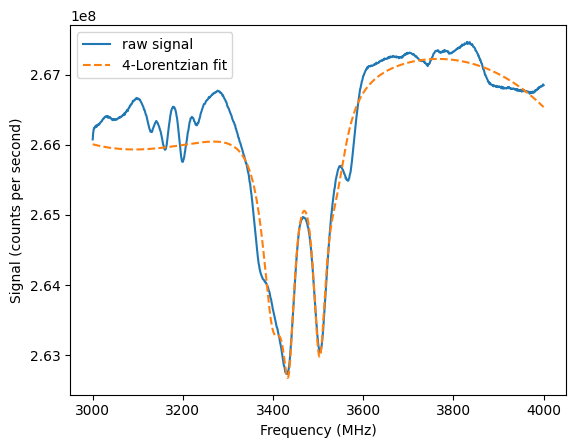

In [25]:
fig, ax = plt.subplots()
ax.plot(frequencies, signal, label="raw signal")
fit_curve = model(frequencies, base_vals_exclude, *popt_exclude)
ax.plot(frequencies, fit_curve, label="4-Lorentzian fit", linestyle="--")
ax.legend()
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (counts per second)")
plt.show()